## gH2AX foci finder

This code reads in foci information obtained from spot-findr and spot-filtrr and calculates distances between spots on a given channel and their nearest neighbors in another

In [1]:
# Import necessary packages

import os
import glob
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotnine as p9
from skimage import feature, io
from scipy.spatial import cKDTree

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

In [2]:
# Define path names and data folders to process

# Define the location of the file to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # modify if needed
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory
experiment_list = ["10062025_hCEC_gH2AX-EdU"]

In [12]:
# Read in filtered spot data from spot-filtrr.ipynb

# Initialize a list to hold the cell_metrics data
spot_metrics_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    metrics_path = os.path.join(repo_directory, "results", experiment, "spot_metrics-postBS.csv")
    
    try:
        # Read the CSV files
        metrics_df = pd.read_csv(metrics_path)
        
        # Append the DataFrame to the list
        spot_metrics_list.append(metrics_df)
        
    except Exception as e:
        logging.error(f"Error reading {metrics_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
spot_metrics = pd.concat(spot_metrics_list, ignore_index=True)

In [13]:
# Print the top of the data frame for inspection
print(spot_metrics.head())

                experiment                                          base_name  \
0  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_sg6-2_dCas9-mStayGold_1_MMSta...   
1  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_sg6-2_dCas9-mStayGold_1_MMSta...   
2  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_sg6-2_dCas9-mStayGold_1_MMSta...   
3  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_sg6-2_dCas9-mStayGold_1_MMSta...   
4  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_sg6-2_dCas9-mStayGold_1_MMSta...   

   ROI  channel    x     y  intensity  probability          plasmid  \
0   23        2  925  1943     511.94        0.495  pLenti_sgRNA6-2   
1   23        2  835  1864     453.25        0.506  pLenti_sgRNA6-2   
2   20        2  460  1776     317.38        0.490  pLenti_sgRNA6-2   
3   20        2  514  1701     335.66        0.491  pLenti_sgRNA6-2   
4   19        2  797  1373     718.56        0.562  pLenti_sgRNA6-2   

          genotype   cell_line timepoint  median  maxima       sbr  \
0  dCas9:mStayGo

In [14]:
# Define a function that calculates nearest neighbor distances
# from one query channel to one or more target channels

def nn_dists(
    spots_df: pd.DataFrame,
    q_chan: int,
    t_chans: list[int],
    group_cols: list = ['experiment','base_name','ROI'],
    pixel_size_nm: float = 98.0
) -> pd.DataFrame:
    """
    For each spot in channel `q_chan`, compute distance to the closest spot
    in each channel in `t_chans`, within the same experiment, base_name, and ROI.
    
    Parameters
    ----------
    spots_df : DataFrame
        Must contain columns group_cols + ['channel','x','y'].
    q_chan : int
        The query channel number.
    t_chans : list of int
        One or more target channel numbers.
    group_cols : list of str
        Columns to group by; defaults to ['experiment','base_name','ROI'].
    pixel_size_nm : float
        Size of one pixel in nanometers; defaults to 98 nm/pixel.
    
    Returns
    -------
    DataFrame
        Rows per (query spot × target channel) with columns:
        group_cols + ['x_q','y_q','query_channel','target_channel','nn_dist_px','nn_dist_nm']
    """
    
    records = []
    
    # Iterate per group (one cell in one image)
    for keys, group in spots_df.groupby(group_cols):
        pts_q = group.loc[group['channel'] == q_chan, ['x','y']].to_numpy()
        if len(pts_q) == 0:
            continue
        
        for t_chan in t_chans:
            pts_t = group.loc[group['channel'] == t_chan, ['x','y']].to_numpy()
            
            if len(pts_t) == 0:
                dists_px = np.full(len(pts_q), np.nan)
            else:
                tree = cKDTree(pts_t)
                dists_px, _ = tree.query(pts_q, k=1)
            
            # convert to nanometers
            dists_nm = dists_px * pixel_size_nm
            
            for (x, y), dist_px, dist_nm in zip(pts_q, dists_px, dists_nm):
                rec = dict(zip(group_cols, keys))
                rec.update({
                    'x_q': float(x),
                    'y_q': float(y),
                    'query_channel': q_chan,
                    'target_channel': t_chan,
                    'nn_dist_px': float(dist_px),
                    'nn_dist_nm': float(dist_nm)
                })
                records.append(rec)
    
    return pd.DataFrame.from_records(records)

In [15]:
# Subset the data frame to work with

# Define and select the columns to keep
my_cols = ["experiment", "base_name", "ROI", "channel", "x", "y", 
           "plasmid", "real_spot"]
my_spot_metrics = spot_metrics[my_cols]

# Filter the data frame to use only "real spots" for channel 2 (the locus label) 
# but all spots for the other two channels -- modify as needed
my_spot_metrics = my_spot_metrics[
    ( (my_spot_metrics['channel'] == 2) & (my_spot_metrics['real_spot'] == "Yes") ) 
    | ( my_spot_metrics['channel'].isin([3, 4]) )
].copy()

# Define the query and target channels 
q_chan = 2
t_chans = [3]
# And the pixel size (in nm)
pixel_size = 98

In [16]:
# Optional check

# 1) Confirm all channel-2 rows are real_spot == "Yes"
ch2 = spot_metrics[spot_metrics['channel']==2]
print("Channel 2, real_spot unique values:", ch2['real_spot'].unique())

# 2) Confirm all channel-3/4 rows are present (and that real_spot can be both Yes/No)
ch34 = spot_metrics[spot_metrics['channel'].isin([3,4])]
print("Channel 3/4, real_spot value counts:\n", ch34['real_spot'].value_counts())

# 3) Check per ROI that you actually have both channels in the filtered set
presence = (
    spot_metrics
    .groupby(['experiment','base_name','ROI'])['channel']
    .unique()
    .apply(sorted)
)
print(presence.head(25))

Channel 2, real_spot unique values: ['Yes' 'No']
Channel 3/4, real_spot value counts:
 real_spot
No     26161
Yes     9601
Name: count, dtype: int64
experiment               base_name                                                    ROI
10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_D29_uninfected_1_MMStack_Pos-3-000_000_MIP  2      [3]
                                                                                      3      [3]
                                                                                      4      [3]
                                                                                      5      [3]
                                                                                      6      [3]
                                                                                      8      [3]
                                                                                      9      [3]
                                                                                  

In [17]:
# Calculate the nearest neighbor distances
spot_dists = nn_dists(my_spot_metrics, q_chan = q_chan, t_chans = t_chans, pixel_size_nm = pixel_size)

In [9]:
print(spot_dists.head())

                experiment                                          base_name  \
0  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_D29_uninfected_1_MMStack_Pos-...   
1  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_mStayGold_Cen6-ZF1c_1_MMStack...   
2  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_mStayGold_Cen7-ZF1g_1_MMStack...   
3  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_mStayGold_Cen7-ZF1g_1_MMStack...   
4  10062025_hCEC_gH2AX-EdU  10062025_hCEC_IF_mStayGold_Cen7-ZF1g_1_MMStack...   

   ROI     x_q     y_q  query_channel  target_channel  nn_dist_px   nn_dist_nm  
0   10  1228.0  1229.0              2               3   20.615528  2020.321757  
1   25   492.0  1704.0              2               3    2.828427   277.185858  
2    2   467.0   197.0              2               3    5.656854   554.371716  
3    2   549.0   171.0              2               3    3.162278   309.903211  
4    3   245.0   294.0              2               3   13.341664  1307.483078  


In [18]:
# Incorporate metadata into spot_dists
my_cols = ["experiment", "base_name", "ROI", 
           "genotype", "cell_line", "timepoint",
           "plasmid"]
spot_dists = pd.merge(spot_dists, 
                      spot_metrics[my_cols], on = ["experiment", "base_name", "ROI"], how = 'inner')

/Users/nestor/anaconda3/envs/pyimage-env/lib/python3.12/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ecdf : Removed 476 rows containing non-finite values.


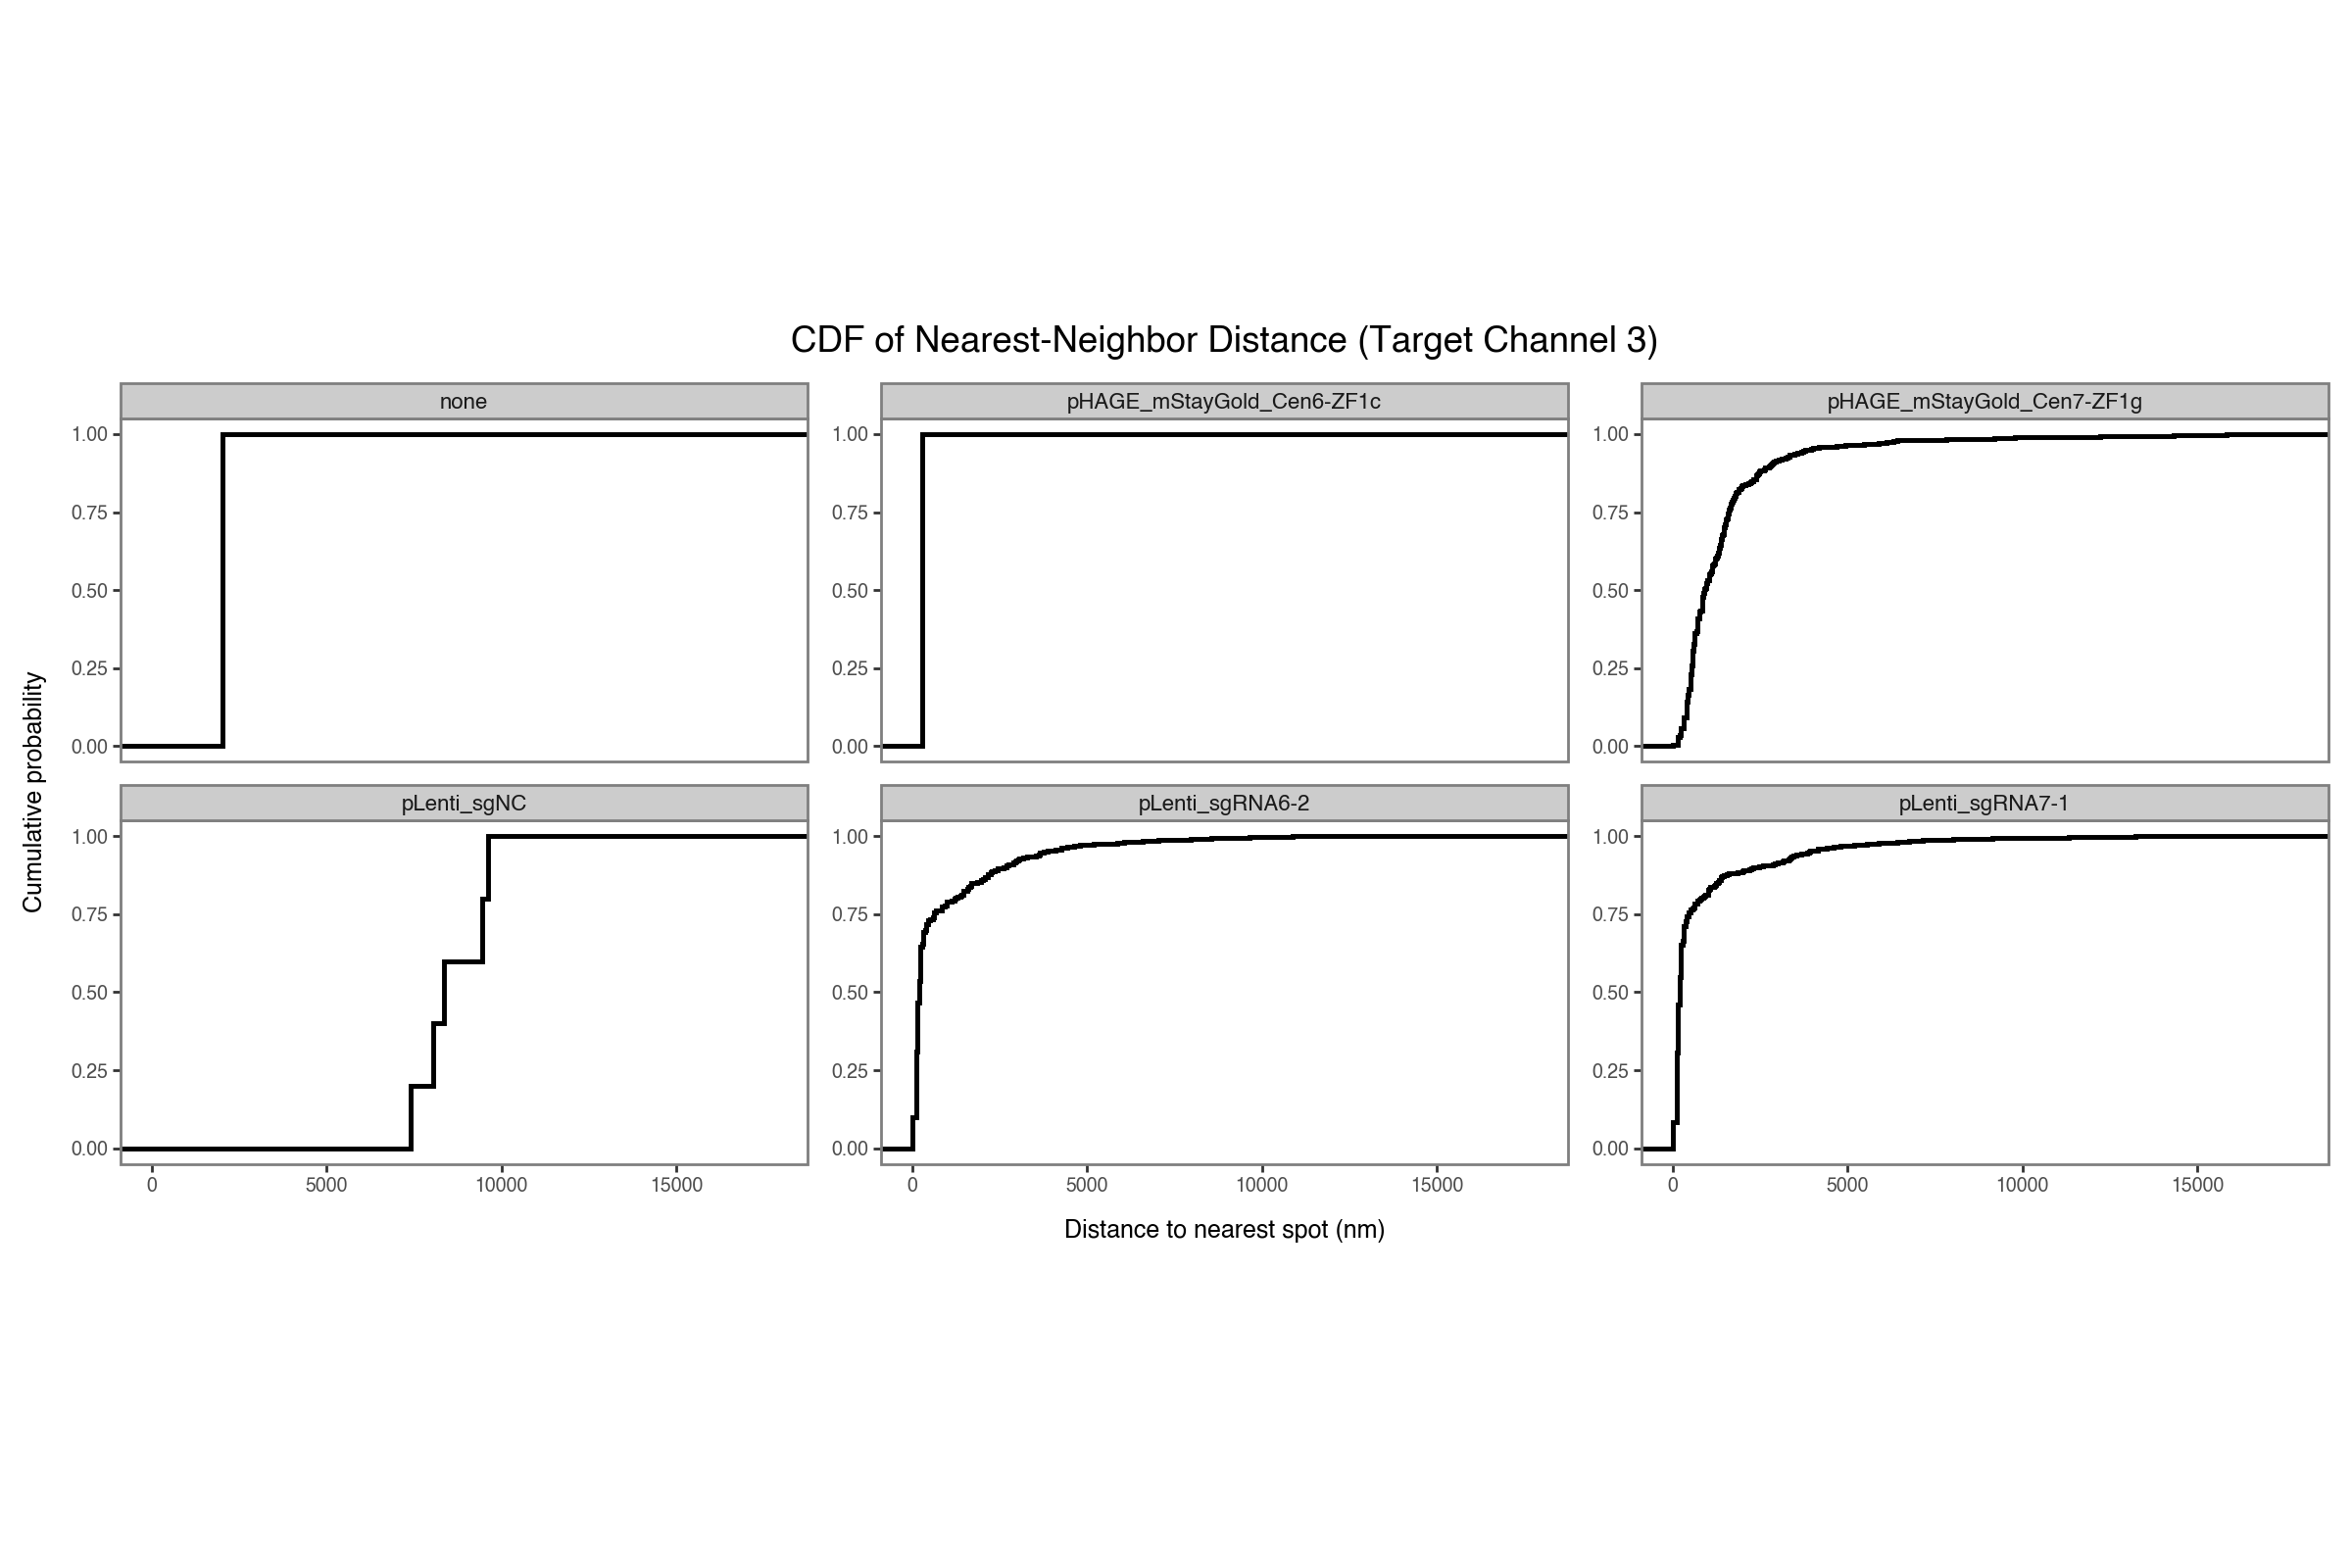

In [19]:
# Make a basic CDF plot of the distances
import plotnine as p9

# Subset to only the distances for the desired target channel
tc = 3
my_df = spot_dists[spot_dists['target_channel'] == tc]

cdf_plot = (
    p9.ggplot(my_df, p9.aes(x = 'nn_dist_nm'))
    + p9.stat_ecdf(size=1, group = 'target_channel')
    + p9.facet_wrap('~ plasmid', scales='free_y')
    + p9.labs(
        title=f'CDF of Nearest-Neighbor Distance (Target Channel {tc})',
        x='Distance to nearest spot (nm)',
        y='Cumulative probability',
        color='Genotype'
    )
    + p9.theme_bw()
    + p9.theme(
        figure_size=(12, 8),
        aspect_ratio=1/2,
        panel_grid=p9.element_blank(),
        strip_text=p9.element_text(size=8),
        axis_text=p9.element_text(size=7),
        axis_title=p9.element_text(size=9),
        legend_position='right'
    )
)

# Display
cdf_plot

In [20]:
# FILE SAVING

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the Data Frame for the current experiment.
    # (Assumes your spot_dists data frame includes an "experiment" column.)
    nn_dist_exp = spot_dists[spot_dists['experiment'] == experiment]
    
    # Define the default file path for the CSV file
    spot_dists_file = os.path.join(experiment_folder, "nn_dists.csv")
    
    # If the spot_dists file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_dists_file):
        spot_dists_file = os.path.join(experiment_folder, f"nn_dists_{date_suffix}.csv")
    
    # Save the data frame to its CSV file
    nn_dist_exp.to_csv(spot_dists_file, index=False)